# Perform the Classification using Bayes Classifier and Naive Bayes Classifier

## Import libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import multivariate_normal
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


## Step 1: Load the dataset and prepare the train, validation, and test Data

In [16]:
# Load datasets
df = pd.read_csv('Date_Fruit_Datasets.csv')

# Display first few rows of train data
print(df.head())

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("\nFeatures (X) shape:", X.shape)
print("Target  (y) shape:", y.shape)
print("\nNumber of features:", X.shape[1])
print("Number of classes :", y.nunique())
print("Classes           :", sorted(y.unique()))

# --------------------------------------------------------------------------
# First split  →  60% Train  |  40% Temp (Validation + Test)
# --------------------------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# --------------------------------------------------------------------------
# Second split  →  Temp split equally into 20% Validation | 20% Test
# --------------------------------------------------------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Print sizes
print("Split Summary:")
print(f"  Training set  : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set      : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification
print("\nClass distribution per split:")
print(f"  Train :  {y_train.value_counts().sort_index().tolist()}")
print(f"  Val   :  {y_val.value_counts().sort_index().tolist()}")
print(f"  Test  :  {y_test.value_counts().sort_index().tolist()}")

     AREA  PERIMETER  MAJOR_AXIS  MINOR_AXIS  ECCENTRICITY   EQDIASQ  \
0  422163   2378.908    837.8484    645.6693        0.6373  733.1539   
1  338136   2085.144    723.8198    595.2073        0.5690  656.1464   
2  526843   2647.394    940.7379    715.3638        0.6494  819.0222   
3  416063   2351.210    827.9804    645.2988        0.6266  727.8378   
4  347562   2160.354    763.9877    582.8359        0.6465  665.2291   

   SOLIDITY  CONVEX_AREA  EXTENT  ASPECT_RATIO  ...  KurtosisRR  KurtosisRG  \
0    0.9947       424428  0.7831        1.2976  ...      3.2370      2.9574   
1    0.9974       339014  0.7795        1.2161  ...      2.6228      2.6350   
2    0.9962       528876  0.7657        1.3150  ...      3.7516      3.8611   
3    0.9948       418255  0.7759        1.2831  ...      5.0401      8.6136   
4    0.9908       350797  0.7569        1.3108  ...      2.7016      2.9761   

   KurtosisRB    EntropyRR    EntropyRG    EntropyRB  ALLdaub4RR  ALLdaub4RG  \
0      4.228

## Bayes classifier implementation steps

### 1. Compute mean and covariance matrix of each class
### 2. Computer Prior probability of each class
### 3. For each test example/sample and for each class, calculate likelihood, prior probability, total probability, and then posterior probability
##### Find likelihood, used allow_singular=True (in case you got any a singular covariance matrix), x is the features from validation or test
likelihood = multivariate_normal(mean=Mean_of_a_Class, cov=CovarianceMatrix_of_a_Class, allow_singular=True).pdf(x)
##### Find prior probability of each class
prior = number_of_samples_in_a_class / number_of_total_samples_in_training_data 
##### Find (likelihood * prior probability) of each class
##### Find total  probability by adding (likelihood * prior probability) of all classes
##### Find posterior probability with each classes
posterior = (likelihood * prior)/total_probability
### 4. Now, for each test sample, we have c number of posterior probability. Here, c is the number of classes/targets. Find for which class, posterior probability is maximum and assign this class label to the test sample.
### 5. Get the prediction label for each test sample and evaluate the performance metrics


In [25]:
# Write the code for Bayes Classifier

# Get all class labels
classes = np.unique(y_train)

# Parameter estimation from train data
class_means, class_covs, class_priors = {}, {}, {}

for cls in classes:
    # Group the training feature vectors with respective classes
    X_cls = X_train[y_train == cls]
    # Calculate mean, co-variance matix, and prior probability from each class of training data
    class_means[cls] = np.mean(X_cls, axis=0)
    class_covs[cls] = np.cov(X_cls, rowvar=False)
    class_priors[cls] = X_cls.shape[0] / X_train.shape[0]

print("Finished Parameter Estimation\n")

# #################### Method-1 ####################
# predictions_test = []
# # For each sample in test data
# for x in X_test:
#     posteriors = []
#     total_prob = 0
#     # For each class
#     for cls in classes:
#         # Calculate likelihood
#         likelihood = multivariate_normal.pdf(
#             x,
#             mean=class_means[cls],
#             cov=class_covs[cls],
#             allow_singular=True
#         )
#         # Calculate numerator term
#         numerator = likelihood * class_priors[cls]
#         # Calculate total probability
#         total_prob += numerator
#         # Calculate posterior probability
#         posterior = numerator/total_prob
#         # Collect all posterior probability of each class for a test sample
#         posteriors.append(posterior)

#     # Predict/Decide the class label
#     label = classes[np.argmax(posteriors)]
#     # Collect all predicted class label for each test sample
#     predictions_test.append(classes[np.argmax(posteriors)])

# print("Finished Test Prediction\n")
# ##################################################

#################### Method-2 ####################
numerators = []
# For each class
for cls in classes:
    # Calculate likelihood for all samples in test data of given class
    likelihood = multivariate_normal.pdf(
        np.array(X_test),
        mean=class_means[cls],
        cov=class_covs[cls],
        allow_singular=True
    )
    
    # Calculate numerator term for all samples of a class
    numerator = likelihood * class_priors[cls]
    # Collect numerator term for all samples of all classes
    numerators.append(numerator)

numerators = np.array(numerators)

# Calculate total probability for all samples
total_probabilities = np.sum(numerators, axis=0).reshape(1, -1)

# Calculate posterior probability for all samples with all classes
posteriors = numerators/total_probabilities

# Predict/Decide the class label for all samples
predictions_test = classes[np.argmax(posteriors, axis=0)]

print(f" Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")


numerators = np.swapaxes(numerators, 0, 1)
total_probabilities = np.sum(numerators, axis=1).reshape(-1, 1)
posteriors = numerators/total_probabilities
predictions_test = classes[np.argmax(posteriors, axis=1)]
print(f"\n Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")
print("\nFinished Test Prediction\n")
##################################################

Finished Parameter Estimation

 Numerator Shape: (7, 180) 
 Total Probability Shape: (1, 180) 
 Posterior Probability Shape: (7, 180) 
 Prediction Shape: (180,)

 Numerator Shape: (180, 7) 
 Total Probability Shape: (180, 1) 
 Posterior Probability Shape: (180, 7) 
 Prediction Shape: (180,)

Finished Test Prediction



## Performance metrics evaluation for Bayes classifier

### Find covariance matrix, accuracy, precision, recall, and f1-score for validation and test data for all classification algorithms.

(180,) (180,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[ 1  2  1  6  1  0  2]
 [ 1 12  2  1  2  0  2]
 [ 0  1 39  0  0  1  0]
 [ 1  1  1 11  0  0  0]
 [ 3  2  0  0 27  0  1]
 [ 0  1  2  2  0 35  0]
 [ 0  7  1  0  2  0  9]]
Accuracy: 0.7444444444444445
Precision (Micro): 0.7444444444444445
Recall (Micro): 0.7444444444444445
F1-score (Micro): 0.7444444444444445
Precision (Macro): 0.6406943686058594
Recall (Macro): 0.6543889862200885
F1-score (Macro): 0.6382698919713695


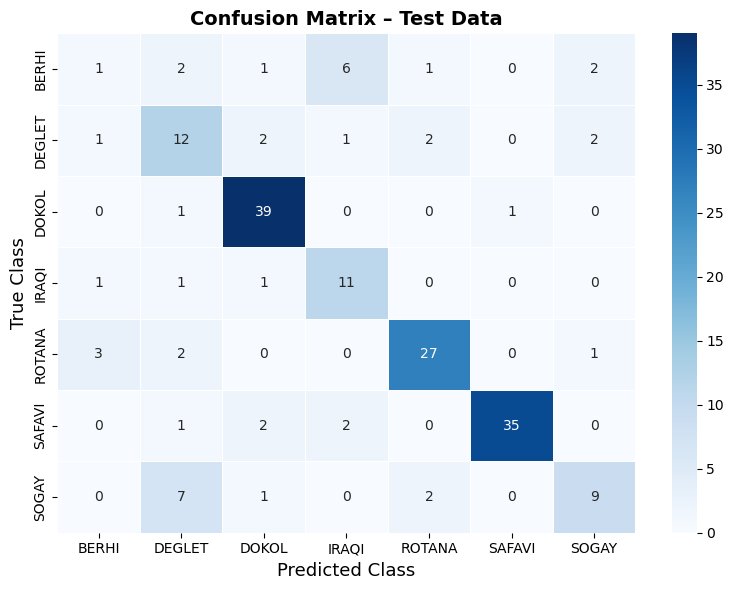

In [28]:
# Write the code for performance metrics evaluation
def evaluate_performance(y_true, y_pred, dataset_name):
    print(f"\nPerformance on {dataset_name} Data")
    print("-" * 40)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("Precision (Micro):", precision_score(y_true, y_pred, average="micro"))
    print("Recall (Micro):", recall_score(y_true, y_pred, average="micro"))
    print("F1-score (Micro):", f1_score(y_true, y_pred, average="micro"))

    print("Precision (Macro):", precision_score(y_true, y_pred, average="macro"))
    print("Recall (Macro):", recall_score(y_true, y_pred, average="macro"))
    print("F1-score (Macro):", f1_score(y_true, y_pred, average="macro"))


def plot_confusion_matrix(y_true, y_pred, label, cmap='Blues'):
    """
    Plot a labelled confusion-matrix heatmap.
    """
    labels = sorted(np.unique(y_true))
    cm     = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                cbar=True, linewidths=0.5)
    plt.xlabel('Predicted Class', fontsize=13)
    plt.ylabel('True Class',      fontsize=13)
    plt.title(f'Confusion Matrix – {label} Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

## Naive Bayes classifier (Using GaussianNB)

In [30]:
# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_test = nb.predict(X_test)


## Performance metrics evaluation for Naive Bayes classifier

### Find covariance matrix, accuracy, precision, recall, and f1-score for validation and test data for all classification algorithms.

(180,) (180,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[ 1  0  4  5  1  0  2]
 [ 2  2  2  5  2  0  7]
 [ 0  1 23  1  0  8  8]
 [ 1  0  5  6  1  0  1]
 [ 6  0  0  0 27  0  0]
 [ 0  0  8  0  0 32  0]
 [ 4  0  8  0  1  0  6]]
Accuracy: 0.5388888888888889
Precision (Micro): 0.5388888888888889
Recall (Micro): 0.5388888888888889
F1-score (Micro): 0.5388888888888889
Precision (Macro): 0.49211234493797523
Recall (Macro): 0.4429202010166617
F1-score (Macro): 0.43577391363592577


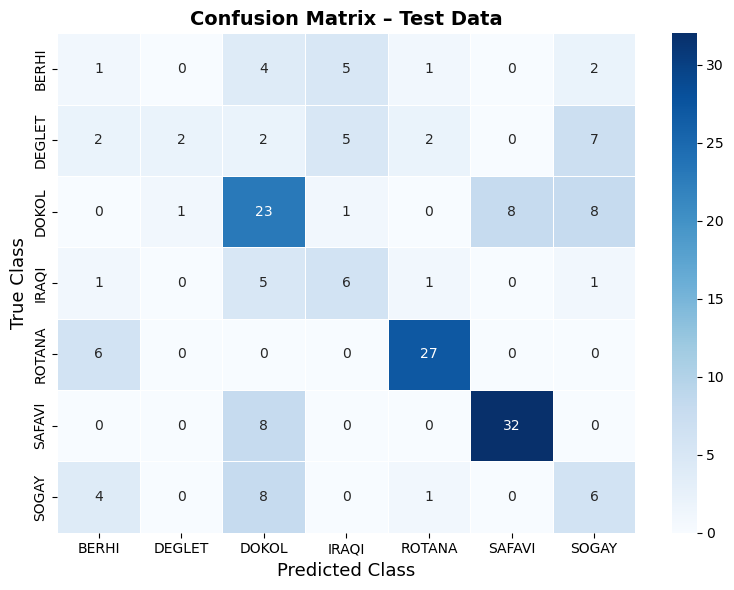

In [31]:
# Write the code for performance metrics evaluation
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")